This file is for fixing class imbalances 

I have tried class weights method in my previous experiment file 

In this file i will be using weighted random sampler(oversampling), minority augmentation, under-sampling, hybrid sampling

In [1]:
import pandas as pd
import regex as re
import torch

In [2]:
df = pd.read_csv(r'D:\Traffic\labels_processed.csv')

In [3]:
def label_function(dpath):
    class_name = re.findall(r'(\d+)_.*\.png$', dpath.name)
    class_id = int(class_name[0])
    return class_id

In [4]:
from pathlib import Path

In [6]:
path = Path(r'D:\Traffic\traffic_Data_processed\DATA')

In [7]:
lr_head = 0.0017378008365631102
lr_whole_model = 1.9054607491852948e-06

In [8]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
from torch.utils.data import Dataset
from PIL import Image

In [10]:
class dset(Dataset):
    def __init__(self, image_paths, transform = None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        label = label_function(Path(image_path))
        if self.transform:
            image = self.transform(image)
        return image, label

In [11]:
image_paths = list(path.rglob("*.png"))

In [12]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = dset(image_paths = image_paths, transform = transform)

In [13]:
from torch.utils.data import random_split

ts = int(0.75*len(dataset))
vs = len(dataset) - ts
generator = torch.Generator().manual_seed(42)
train_dataset, valid_dataset = random_split(dataset, [ts, vs], generator)

In [14]:
from torch.utils.data import DataLoader

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False
)

In [16]:
import torchvision
num_classes = 55
device = torch.device("cuda")

In [17]:
import kornia.augmentation as K
import torch.nn as nn

In [18]:
model_1 = torchvision.models.resnet34(weights="DEFAULT")
model_1.fc = nn.Linear(
    model_1.fc.in_features,
    num_classes
)

model_1 = model_1.to(device)

for param in model_1.parameters():
    param.requires_grad = False

for param in model_1.fc.parameters():
    param.requires_grad = True

train_aug_1 = K.AugmentationSequential(
    K.ColorJiggle(
        contrast = 0.2,
        p = 0.5
    ),
    K.RandomPlanckianJitter(
        mode = "CIED",
        p = 0.5
    )
).to(device)

optimizer_1 = torch.optim.RMSprop(
    model_1.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1,
    max_lr = lr_head,
    epochs = 20,
    steps_per_epoch = len(train_loader)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    model_1.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug_1(images)

        optimizer_1.zero_grad()

        outputs = model_1(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_1.step()

        scheduler_1.step()          

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total


    model_1.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_1(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/20 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/20 | Train Acc: 63.70% | Valid Acc: 88.44%
Epoch 2/20 | Train Acc: 88.37% | Valid Acc: 93.06%
Epoch 3/20 | Train Acc: 85.96% | Valid Acc: 87.48%
Epoch 4/20 | Train Acc: 86.77% | Valid Acc: 87.86%
Epoch 5/20 | Train Acc: 88.40% | Valid Acc: 94.32%
Epoch 6/20 | Train Acc: 89.46% | Valid Acc: 90.46%
Epoch 7/20 | Train Acc: 88.98% | Valid Acc: 92.97%
Epoch 8/20 | Train Acc: 89.72% | Valid Acc: 94.89%
Epoch 9/20 | Train Acc: 91.49% | Valid Acc: 89.88%
Epoch 10/20 | Train Acc: 92.16% | Valid Acc: 93.64%
Epoch 11/20 | Train Acc: 90.91% | Valid Acc: 96.05%
Epoch 12/20 | Train Acc: 93.03% | Valid Acc: 94.89%
Epoch 13/20 | Train Acc: 92.68% | Valid Acc: 96.34%
Epoch 14/20 | Train Acc: 94.25% | Valid Acc: 94.22%
Epoch 15/20 | Train Acc: 95.09% | Valid Acc: 95.18%
Epoch 16/20 | Train Acc: 95.86% | Valid Acc: 97.21%
Epoch 17/20 | Train Acc: 97.85% | Valid Acc: 97.88%
Epoch 18/20 | Train Acc: 98.55% | Valid Acc: 98.36%
Epoch 19/20 | Train Acc: 99.20% | Valid Acc: 98.94%
Epoch 20/20 | Train A

In [20]:
l = list()
for x in range(55):
    n = len(list(Path(path/f'{x}').rglob("*.png")))
    l.append(1/float(n))

In [21]:
from torch.utils.data import WeightedRandomSampler

In [22]:
sample_weights = []

for idx in train_dataset.indices:
    image_path = dataset.image_paths[idx]
    label = label_function(Path(image_path))
    sample_weights.append(l[label])

sample_weights = torch.tensor(sample_weights, dtype=torch.double)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_2 = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler
)


model_2 = torchvision.models.resnet34(weights="DEFAULT")

model_2.fc = nn.Linear(
    model_2.fc.in_features,
    num_classes
)

model_2 = model_2.to(device)

for param in model_2.parameters():
    param.requires_grad = False

for param in model_2.fc.parameters():
    param.requires_grad = True


train_aug = K.AugmentationSequential(
    K.ColorJiggle(
        contrast=0.2,
        p=0.5
    ),
    K.RandomPlanckianJitter(
        mode="CIED",
        p=0.5
    )
).to(device)


optimizer_2 = torch.optim.RMSprop(
    model_2.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_2,
    max_lr=lr_head,
    epochs=20,
    steps_per_epoch=len(train_loader_2)
)

criterion = nn.CrossEntropyLoss()


for epoch in range(20):

    model_2.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_2:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug(images)

        optimizer_2.zero_grad()

        outputs = model_2(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_2.step()

        scheduler_2.step()

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)


    train_acc = 100 * train_correct / train_total


    model_2.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_2(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)


    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/20 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/20 | Train Acc: 65.79% | Valid Acc: 84.39%
Epoch 2/20 | Train Acc: 89.91% | Valid Acc: 87.28%
Epoch 3/20 | Train Acc: 88.02% | Valid Acc: 90.08%
Epoch 4/20 | Train Acc: 88.24% | Valid Acc: 79.19%
Epoch 5/20 | Train Acc: 86.80% | Valid Acc: 86.51%
Epoch 6/20 | Train Acc: 90.04% | Valid Acc: 88.63%
Epoch 7/20 | Train Acc: 89.82% | Valid Acc: 89.21%
Epoch 8/20 | Train Acc: 90.84% | Valid Acc: 91.33%
Epoch 9/20 | Train Acc: 91.42% | Valid Acc: 87.96%
Epoch 10/20 | Train Acc: 91.49% | Valid Acc: 90.17%
Epoch 11/20 | Train Acc: 91.65% | Valid Acc: 92.87%
Epoch 12/20 | Train Acc: 92.23% | Valid Acc: 91.62%
Epoch 13/20 | Train Acc: 93.25% | Valid Acc: 93.93%
Epoch 14/20 | Train Acc: 95.02% | Valid Acc: 90.08%
Epoch 15/20 | Train Acc: 94.89% | Valid Acc: 94.12%
Epoch 16/20 | Train Acc: 96.95% | Valid Acc: 96.53%
Epoch 17/20 | Train Acc: 97.43% | Valid Acc: 97.50%
Epoch 18/20 | Train Acc: 98.55% | Valid Acc: 98.07%
Epoch 19/20 | Train Acc: 99.29% | Valid Acc: 97.59%
Epoch 20/20 | Train A

As we can see that this is worse than normal training and this is because sampler is operating only on training dataset and validation dataset is still not balanced and so this is creating train–validation distribution mismatch.

So again making a code cell but in that i will be using weighted random sampler correctly

In [23]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler, DataLoader

train_labels = []

for idx in train_dataset.indices:
    image_path = dataset.image_paths[idx]
    label = label_function(Path(image_path))
    train_labels.append(label)

class_counts = Counter(train_labels)

class_weights = {
    cls: 1.0 / count
    for cls, count in class_counts.items()
}

sample_weights = [
    class_weights[label]
    for label in train_labels
]

sample_weights = torch.tensor(
    sample_weights,
    dtype=torch.double
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_3 = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler
)

model_3 = torchvision.models.resnet34(weights="DEFAULT")

model_3.fc = nn.Linear(
    model_3.fc.in_features,
    num_classes
)

model_3 = model_3.to(device)


for param in model_3.parameters():
    param.requires_grad = False

for param in model_3.fc.parameters():
    param.requires_grad = True

train_aug = K.AugmentationSequential(
    K.ColorJiggle(
        contrast=0.2,
        p=0.5
    ),
    K.RandomPlanckianJitter(
        mode="CIED",
        p=0.5
    )
).to(device)

optimizer_3 = torch.optim.RMSprop(
    model_3.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_3 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_3,
    max_lr=lr_head,
    epochs=20,
    steps_per_epoch=len(train_loader_3)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(20):

    model_3.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_3:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug(images)

        optimizer_3.zero_grad()

        outputs = model_3(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_3.step()

        scheduler_3.step()

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total

    model_3.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_3(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()
            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/20 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/20 | Train Acc: 67.23% | Valid Acc: 82.66%
Epoch 2/20 | Train Acc: 90.30% | Valid Acc: 87.38%
Epoch 3/20 | Train Acc: 86.73% | Valid Acc: 85.26%
Epoch 4/20 | Train Acc: 88.89% | Valid Acc: 88.92%
Epoch 5/20 | Train Acc: 88.24% | Valid Acc: 91.04%
Epoch 6/20 | Train Acc: 88.40% | Valid Acc: 87.28%
Epoch 7/20 | Train Acc: 90.46% | Valid Acc: 90.37%
Epoch 8/20 | Train Acc: 89.69% | Valid Acc: 89.60%
Epoch 9/20 | Train Acc: 91.07% | Valid Acc: 87.28%
Epoch 10/20 | Train Acc: 93.13% | Valid Acc: 89.40%
Epoch 11/20 | Train Acc: 91.13% | Valid Acc: 93.45%
Epoch 12/20 | Train Acc: 93.61% | Valid Acc: 88.34%
Epoch 13/20 | Train Acc: 93.03% | Valid Acc: 94.22%
Epoch 14/20 | Train Acc: 93.80% | Valid Acc: 89.02%
Epoch 15/20 | Train Acc: 95.60% | Valid Acc: 96.24%
Epoch 16/20 | Train Acc: 96.72% | Valid Acc: 97.69%
Epoch 17/20 | Train Acc: 97.14% | Valid Acc: 97.30%
Epoch 18/20 | Train Acc: 99.36% | Valid Acc: 97.69%
Epoch 19/20 | Train Acc: 99.20% | Valid Acc: 98.17%
Epoch 20/20 | Train A

In [25]:
from collections import Counter
from torch.utils.data import DataLoader

train_labels = []

for idx in train_dataset.indices:
    image_path = dataset.image_paths[idx]
    label = label_function(Path(image_path))
    train_labels.append(label)

class_counts = Counter(train_labels)

minority_classes = {
    cls for cls, count in class_counts.items()
    if count < 50
}

train_loader_4 = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

train_aug = K.AugmentationSequential(
    K.ColorJiggle(
        contrast=0.2,
        p=0.5
    ),
    K.RandomPlanckianJitter(
        mode="CIED",
        p=0.5
    )
).to(device)

minority_aug = K.AugmentationSequential(
    K.ColorJiggle(
        brightness=0.2,
        contrast=0.2,
        p=0.5
    ),
    K.RandomAffine(
        degrees=10,
        scale=(0.9, 1.1),
        p=0.5
    ),
    K.RandomPerspective(
        distortion_scale=0.2,
        p=0.5
    )
).to(device)

model_4 = torchvision.models.resnet34(weights="DEFAULT")

model_4.fc = nn.Linear(
    model_4.fc.in_features,
    num_classes
)

model_4 = model_4.to(device)

for param in model_4.parameters():
    param.requires_grad = False

for param in model_4.fc.parameters():
    param.requires_grad = True

optimizer_4 = torch.optim.RMSprop(
    model_4.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_4 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_4,
    max_lr=lr_head,
    epochs=20,
    steps_per_epoch=len(train_loader_4)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(20):

    model_4.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_4:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug(images)

        minority_mask = torch.tensor(
            [label.item() in minority_classes for label in labels],
            device=device
        )

        if minority_mask.any():
            images[minority_mask] = minority_aug(
                images[minority_mask]
            )

        optimizer_4.zero_grad()

        outputs = model_4(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_4.step()

        scheduler_4.step()

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total

    model_4.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_4(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()
            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/20 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/20 | Train Acc: 63.12% | Valid Acc: 87.19%
Epoch 2/20 | Train Acc: 85.54% | Valid Acc: 90.17%
Epoch 3/20 | Train Acc: 86.57% | Valid Acc: 89.60%
Epoch 4/20 | Train Acc: 85.74% | Valid Acc: 85.74%
Epoch 5/20 | Train Acc: 87.09% | Valid Acc: 88.34%
Epoch 6/20 | Train Acc: 87.86% | Valid Acc: 89.02%
Epoch 7/20 | Train Acc: 88.24% | Valid Acc: 89.40%
Epoch 8/20 | Train Acc: 87.12% | Valid Acc: 93.64%
Epoch 9/20 | Train Acc: 89.78% | Valid Acc: 93.16%
Epoch 10/20 | Train Acc: 90.65% | Valid Acc: 92.77%
Epoch 11/20 | Train Acc: 91.10% | Valid Acc: 92.49%
Epoch 12/20 | Train Acc: 91.04% | Valid Acc: 91.81%
Epoch 13/20 | Train Acc: 92.45% | Valid Acc: 93.93%
Epoch 14/20 | Train Acc: 93.93% | Valid Acc: 94.12%
Epoch 15/20 | Train Acc: 94.19% | Valid Acc: 95.38%
Epoch 16/20 | Train Acc: 94.76% | Valid Acc: 95.57%
Epoch 17/20 | Train Acc: 96.40% | Valid Acc: 96.24%
Epoch 18/20 | Train Acc: 97.82% | Valid Acc: 97.78%
Epoch 19/20 | Train Acc: 98.84% | Valid Acc: 98.55%
Epoch 20/20 | Train A

As we can see that our dataset is highly imbalanced and so undersampling is somewhat illogical and so we will be using undersampling in hybrid sampling

here goes that experiment with 80 images of each class and minority augmentation as well for oversampled classes

In [26]:
from collections import defaultdict
from torch.utils.data import Subset

train_labels = []

for idx in train_dataset.indices:
    image_path = dataset.image_paths[idx]
    label = label_function(Path(image_path))
    train_labels.append(label)

class_indices = defaultdict(list)

for idx, label in zip(train_dataset.indices, train_labels):
    class_indices[label].append(idx)

target_count = 80

selected_indices = []
oversampled_classes = set()

generator = torch.Generator().manual_seed(42)

for cls, indices in class_indices.items():

    if len(indices) > target_count:
        selected = torch.randperm(
            len(indices),
            generator=generator
        )[:target_count]

        selected_indices.extend(
            [indices[i] for i in selected.tolist()]
        )

    elif len(indices) < target_count:
        oversampled_classes.add(cls)

        selected = torch.randint(
            0,
            len(indices),
            (target_count,),
            generator=generator
        )

        selected_indices.extend(
            [indices[i] for i in selected.tolist()]
        )

    else:
        selected_indices.extend(indices)

hybrid_train_dataset = Subset(
    dataset,
    selected_indices
)

train_loader_5 = DataLoader(
    hybrid_train_dataset,
    batch_size=16,
    shuffle=True
)

train_aug = K.AugmentationSequential(
    K.ColorJiggle(
        contrast=0.2,
        p=0.5
    ),
    K.RandomPlanckianJitter(
        mode="CIED",
        p=0.5
    )
).to(device)

minority_aug = K.AugmentationSequential(
    K.ColorJiggle(
        brightness=0.2,
        contrast=0.2,
        p=0.5
    ),
    K.RandomAffine(
        degrees=10,
        scale=(0.9, 1.1),
        p=0.5
    ),
    K.RandomPerspective(
        distortion_scale=0.2,
        p=0.5
    )
).to(device)

model_5 = torchvision.models.resnet34(weights="DEFAULT")

model_5.fc = nn.Linear(
    model_5.fc.in_features,
    num_classes
)

model_5 = model_5.to(device)

for param in model_5.parameters():
    param.requires_grad = False

for param in model_5.fc.parameters():
    param.requires_grad = True

optimizer_5 = torch.optim.RMSprop(
    model_5.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_5 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_5,
    max_lr=lr_head,
    epochs=20,
    steps_per_epoch=len(train_loader_5)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(20):

    model_5.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_5:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug(images)

        minority_mask = torch.tensor(
            [label.item() in oversampled_classes for label in labels],
            device=device
        )

        if minority_mask.any():
            images[minority_mask] = minority_aug(
                images[minority_mask]
            )

        optimizer_5.zero_grad()

        outputs = model_5(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_5.step()

        scheduler_5.step()

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total

    model_5.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_5(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()
            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/20 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/20 | Train Acc: 67.36% | Valid Acc: 87.09%
Epoch 2/20 | Train Acc: 86.73% | Valid Acc: 75.05%
Epoch 3/20 | Train Acc: 85.55% | Valid Acc: 81.79%
Epoch 4/20 | Train Acc: 85.45% | Valid Acc: 82.27%
Epoch 5/20 | Train Acc: 85.95% | Valid Acc: 90.08%
Epoch 6/20 | Train Acc: 86.25% | Valid Acc: 89.31%
Epoch 7/20 | Train Acc: 87.68% | Valid Acc: 89.60%
Epoch 8/20 | Train Acc: 89.91% | Valid Acc: 87.48%
Epoch 9/20 | Train Acc: 88.02% | Valid Acc: 84.39%
Epoch 10/20 | Train Acc: 89.41% | Valid Acc: 80.35%
Epoch 11/20 | Train Acc: 89.39% | Valid Acc: 86.80%
Epoch 12/20 | Train Acc: 90.93% | Valid Acc: 86.90%
Epoch 13/20 | Train Acc: 90.66% | Valid Acc: 89.60%
Epoch 14/20 | Train Acc: 90.93% | Valid Acc: 91.81%
Epoch 15/20 | Train Acc: 93.36% | Valid Acc: 90.56%
Epoch 16/20 | Train Acc: 94.93% | Valid Acc: 94.61%
Epoch 17/20 | Train Acc: 95.95% | Valid Acc: 94.41%
Epoch 18/20 | Train Acc: 97.73% | Valid Acc: 96.15%
Epoch 19/20 | Train Acc: 98.61% | Valid Acc: 96.15%
Epoch 20/20 | Train A

So we took different sampling methods to see their results and still normal ce loss one without any sampling is the best result giving

Now comapring them on different metrics

In [27]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np

models = {
    "Model 1": model_1,
    "Model 2": model_2,
    "Model 3": model_3,
    "Model 4": model_4,
    "Model 5": model_5
}

results = {}

for name, model in models.items():

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)

            outputs = model(images)

            _, predictions = outputs.max(1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(predictions.cpu().numpy())

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    report = classification_report(
        all_labels,
        all_predictions,
        labels=list(range(num_classes)),
        zero_division=0
    )

    cm = confusion_matrix(
        all_labels,
        all_predictions,
        labels=list(range(num_classes))
    )

    results[name] = {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "report": report,
        "confusion_matrix": cm
    }

    print(f"\n{name}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Macro F1: {macro_f1:.4f}")
    print(report)


Model 1
Accuracy: 98.65%
Macro F1: 0.9750
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        35
           1       0.78      0.78      0.78         9
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        72
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00        50
           6       1.00      1.00      1.00        13
           7       1.00      0.96      0.98        45
           8       1.00      1.00      1.00         1
           9       0.00      0.00      0.00         0
          10       1.00      1.00      1.00        15
          11       1.00      1.00      1.00        37
          12       1.00      1.00      1.00        25
          13       1.00      1.00      1.00         7
          14       1.00      1.00      1.00        36
          15       1.00      1.00      1.00         4
          16       1.00      1.00     

On this dataset and experimental setup, the imbalance-handling strategies tested did not improve overall accuracy or macro-F1 over the normal CE baseline

In [28]:
for name, result in results.items():
    print(
        f"{name}: "
        f"Accuracy = {result['accuracy'] * 100:.2f}% | "
        f"Macro F1 = {result['macro_f1']:.4f}"
    )

Model 1: Accuracy = 98.65% | Macro F1 = 0.9750
Model 2: Accuracy = 98.07% | Macro F1 = 0.9739
Model 3: Accuracy = 97.98% | Macro F1 = 0.9701
Model 4: Accuracy = 98.65% | Macro F1 = 0.9619
Model 5: Accuracy = 96.34% | Macro F1 = 0.9497


In [30]:
cm_1 = results["Model 1"]["confusion_matrix"]
np.set_printoptions(threshold=np.inf)
print(cm_1)

[[ 35   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0]
 [  2   7   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0]
 [  0   0  18   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0]
 [  0   0   0  72   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0]
 [  0   0   0   0  30   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0 

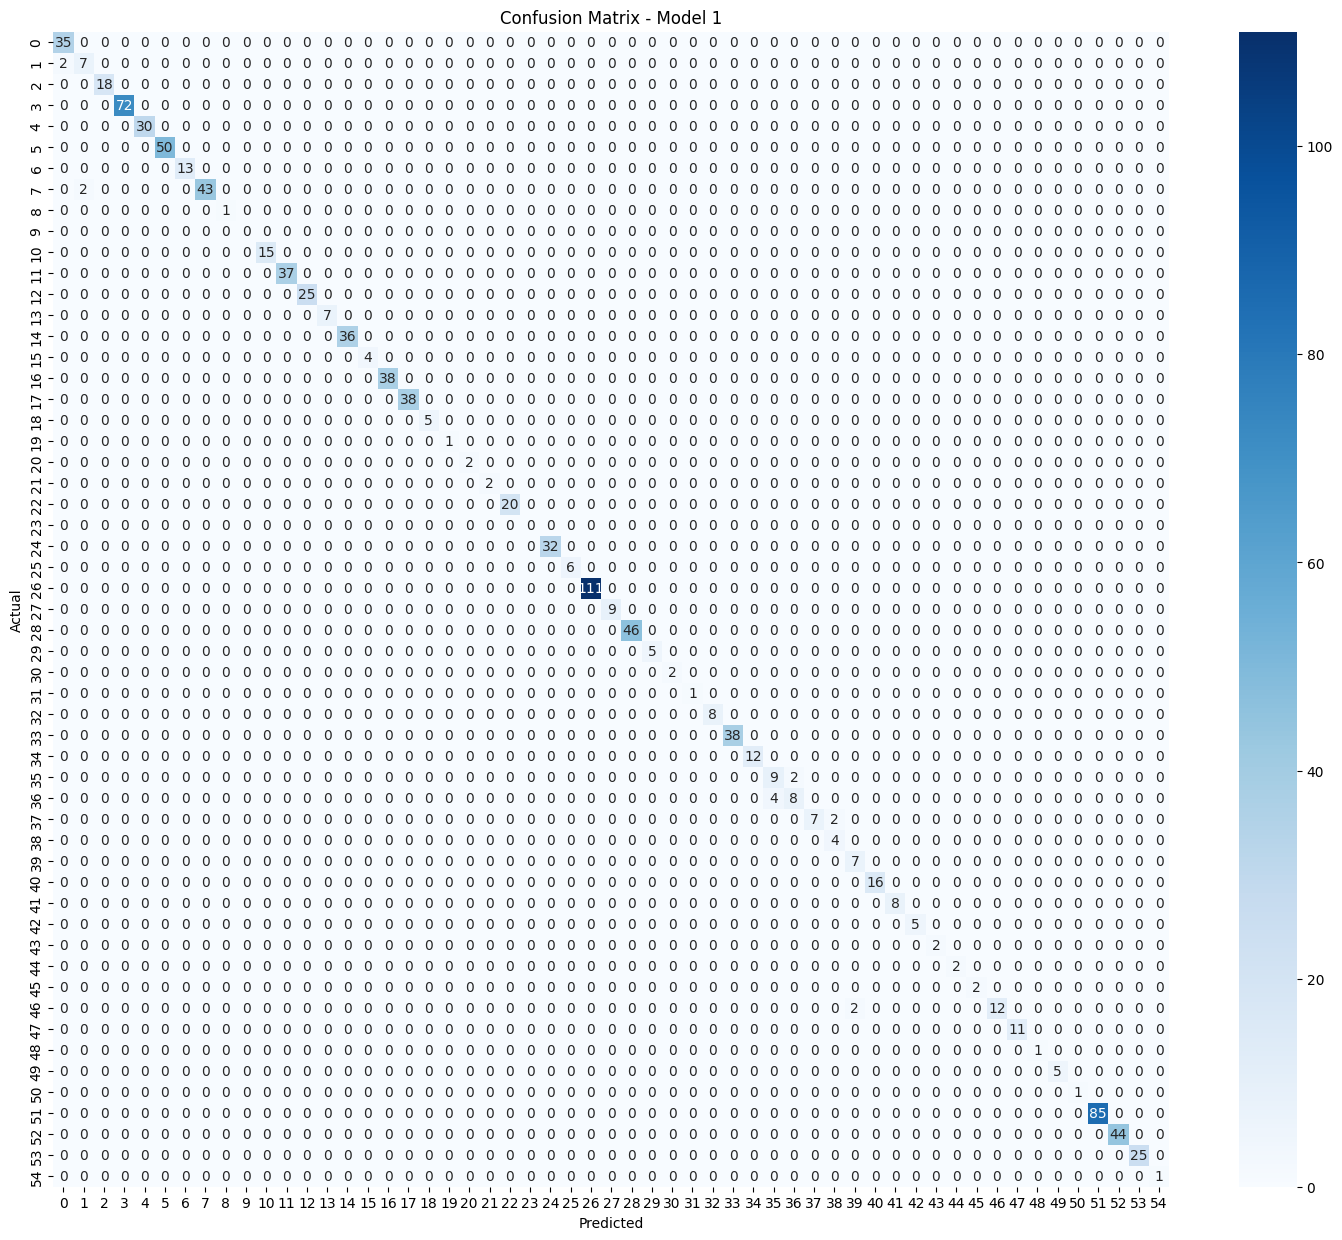

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm_1,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Model 1")

plt.show()

The confusion matrix shows that predictions are highly concentrated along the diagonal, indicating strong classification performance. Most errors are concentrated among a few visually similar classes, particularly classes 35 and 36.